In [21]:
import sys
import os

# detect the environment
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# configure the paths
if IN_COLAB:
    print("Running in Google Colab. Setting up GitHub repo...")
    REPO_URL = "https://github.com/JayC-SF/COMP-432-Project.git"
    REPO_DIR = "/content/COMP-432-Project"
    
    if not os.path.exists(REPO_DIR):
        !git clone {REPO_URL}
        
    if REPO_DIR not in sys.path:
        sys.path.append(REPO_DIR)
    
    !pip install optuna
    
    # change the working directory
    os.chdir(REPO_DIR)
else:
    print("Running locally. Setting up relative paths...")
    # move up only if base directory is at notebooks
    if os.path.basename(os.getcwd()) == 'notebooks':
        os.chdir('..')
        print(f"Working directory changed to: {os.getcwd()}")
    
    # add working dir to sys path
    if os.getcwd() not in sys.path:
        sys.path.append(os.getcwd())
        
    %load_ext autoreload
    %autoreload 2

from src import preprocess_data as prepd
from src.models.NN import AudioCLSTM
import src.variables as v
import numpy as np
import torch
from src.train.orchestrator import Orchestrator
from src.utils.hardware import get_device
from src.utils.seed import set_seed
from src.datasets import ICSD_MelSpectogram
from torch.utils.data import DataLoader
import copy
import gc
import optuna
import joblib
import src.utils.plotting as plotting
import pandas as pd
set_seed(v.SEED)

Running locally. Setting up relative paths...
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✅ Seed set to: 42


Download the mel spectogram `.npz` dataset.

In [22]:
prepd.download_google_file(v.MEL_SPECTOGRAM_NPZ_FILE_PATH, v.MEL_SPECTOGRAM_NPZ_GID)

data/mel_spectogram_audio_length_adjusted.npz already exists.


In [23]:
data = np.load(v.MEL_SPECTOGRAM_NPZ_FILE_PATH)
train_ds = ICSD_MelSpectogram(data['X_train'], data['y_train'])
val_ds = ICSD_MelSpectogram(data['X_val'], data['y_val'])
test_ds = ICSD_MelSpectogram(data['X_test'], data['y_test'])

We load the dataset into their respective splits

In [24]:
set_seed(v.SEED)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)

✅ Seed set to: 42


In [25]:
set_seed(v.SEED)
untrained_CLSTM_model = AudioCLSTM(2)

✅ Seed set to: 42


In [26]:
def create_orchestrator(name, lr, wd, trial=None):
    set_seed(v.SEED)
    
    # use output 2 classes so we can use standard multi class logic for training orchestrator
    LEARNING_RATE = lr
    WEIGHT_DECAY = wd
    PATIENCE = 15
    SAVE_PATH = v.RUNS_PATH/name
    MAX_EPOCHS = 500
    model = copy.deepcopy(untrained_CLSTM_model)
    DEVICE = get_device()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        weight_decay = WEIGHT_DECAY,
        lr=LEARNING_RATE
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        patience=5,
        factor=0.1,
    )
    criterion = torch.nn.CrossEntropyLoss()

    orchestrator = Orchestrator(
        model=model,
        optimizer=optimizer,
        criterion=criterion,
        train_loader=train_loader,
        val_loader=val_loader,
        device=DEVICE,
        patience=PATIENCE,
        save_path=SAVE_PATH,
        scheduler=scheduler,
        max_epochs=MAX_EPOCHS,
        classes=v.CLASSES,
        trial=trial
    )

    return orchestrator

def train_model(name, lr, wd, trial=None):
    orchestrator = create_orchestrator(name, lr, wd, trial)
    print(f"\n🚀 Training {name} | LR: {lr} | WD: {wd}")
    if trial is None:
        print(f"📂 Saving to: {orchestrator.save_path}")

    orchestrator.train()
    return orchestrator

In [8]:
orchestrator_CLSTM_baseline = train_model(name="CLSTM_baseline", lr=5e-4, wd=5e-4)

✅ Seed set to: 42

🚀 Training CLSTM_baseline | LR: 0.0005 | WD: 0.0005
📂 Saving to: runs\CLSTM_baseline
Running with device:cuda
---- Starting Epoch 1 ----


Train Loss: 0.3014 | Train Acc: 86.8528%


Val Loss: 0.2259 | Val Acc: 91.7745%
Saved checkpoint data under runs\CLSTM_baseline\latest_history.pt
🌟 New Best Model! Val Loss decreased from inf to 0.2259
Saved best_model_weights under runs\CLSTM_baseline\best_model.pt
---- Starting Epoch 2 ----


Train Loss: 0.1758 | Train Acc: 93.4712%


Val Loss: 0.1708 | Val Acc: 93.3457%
Saved checkpoint data under runs\CLSTM_baseline\latest_history.pt
🌟 New Best Model! Val Loss decreased from 0.2259 to 0.1708
Saved best_model_weights under runs\CLSTM_baseline\best_model.pt
---- Starting Epoch 3 ----


...

Val Loss: 0.0990 | Val Acc: 97.5046%
Saved checkpoint data under runs\CLSTM_baseline\latest_history.pt
⚠️ No improvement. Early Stopping Counter: 13/15
---- Starting Epoch 33 ----


Train Loss: 0.0078 | Train Acc: 99.7314%


Val Loss: 0.0977 | Val Acc: 97.4122%
Saved checkpoint data under runs\CLSTM_baseline\latest_history.pt
⚠️ No improvement. Early Stopping Counter: 14/15
---- Starting Epoch 34 ----


Train Loss: 0.0077 | Train Acc: 99.7314%


Val Loss: 0.0987 | Val Acc: 97.5046%
Saved checkpoint data under runs\CLSTM_baseline\latest_history.pt
⚠️ No improvement. Early Stopping Counter: 15/15
🛑 Early stopping triggered.
Completed training at epoch 34


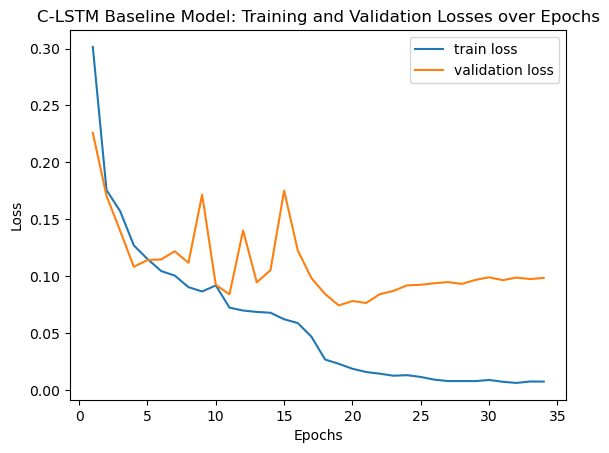

Best model's validation loss (0.07456372386316275) achieved at epoch 19
Best model's training loss (0.02332739161890945)
Total epochs (34)


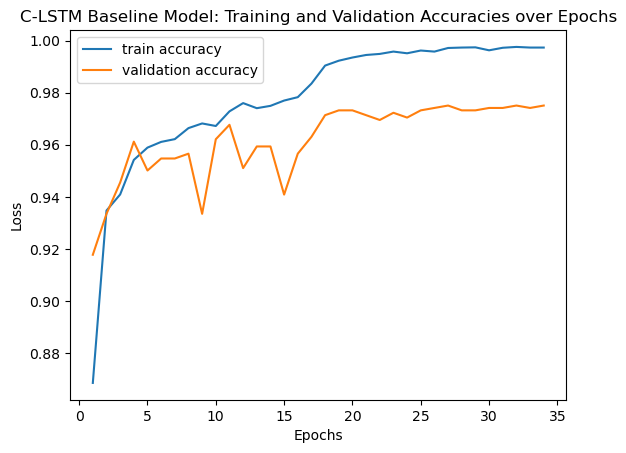

Best epoch's validation accuracy: 97.319778%
Best epoch's training accuracy: 99.226636%


In [44]:
plotting.plot_orchestrator_training_summary(orchestrator_CLSTM_baseline, "C-LSTM Baseline Model")

In [32]:
results_CLSTM_baseline = orchestrator_CLSTM_baseline.test(test_loader, orchestrator_CLSTM_baseline.th.best_model_weights)

Test Loss: 0.0296 | Test Acc: 98.9834%


              precision    recall  f1-score   support

     Snoring       0.98      1.00      0.99       539
   InfantCry       1.00      0.98      0.99       543

    accuracy                           0.99      1082
   macro avg       0.99      0.99      0.99      1082
weighted avg       0.99      0.99      0.99      1082



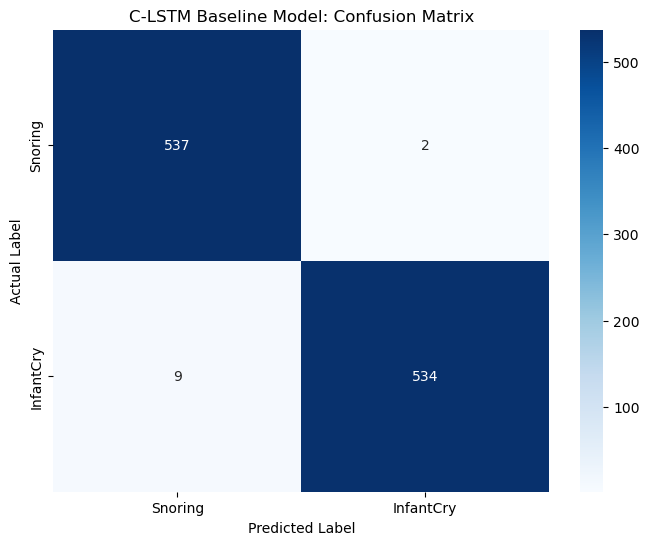

Test Loss: 0.0296 | Test Acc: 98.9834%


In [33]:
plotting.plot_test_results(results_CLSTM_baseline, "C-LSTM Baseline Model")

In [17]:
def objective(trial):
    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    wd = trial.suggest_float("wd", 1e-6, 1e-2, log=True)
    
    orchestrator = train_model(name=f"CLSTM_trial_{trial.number}", lr=lr, wd=wd, trial=trial)
    
    best_val_loss = orchestrator.th.best_val_loss
    
    del orchestrator
    gc.collect() 
    torch.cuda.empty_cache()
    
    return best_val_loss

In [20]:
study = optuna.create_study(
    direction="minimize", 
    study_name="CLSTM_ICSD_Optimization"
)

study.optimize(objective, n_trials=15)
# Save the study object to a file
joblib.dump(study, v.RUNS_PATH/"CLSTM_ICSD_Optimization_Optuna_Study.pkl")

[I 2026-04-18 22:55:24,745] A new study created in memory with name: CLSTM_ICSD_Optimization


✅ Seed set to: 42

🚀 Training CLSTM_trial_0 | LR: 8.882231141835384e-05 | WD: 0.003805184183486251
Running with device:cuda
---- Starting Epoch 1 ----


Train Loss: 0.3487 | Train Acc: 83.8408%


Val Loss: 0.1958 | Val Acc: 91.6821%
🌟 New Best Model! Val Loss decreased from inf to 0.1958
---- Starting Epoch 2 ----


Train Loss: 0.1883 | Train Acc: 92.6083%


...

Train Loss: 0.1409 | Train Acc: 94.7737%


Val Loss: 0.1485 | Val Acc: 94.9168%


[I 2026-04-19 00:28:51,477] Trial 14 pruned. 


✂️ Trial pruned at epoch 3


['runs\\CLSTM_ICSD_Optimization_Optuna_Study.pkl']

In [ ]:
optuna_fname = "CLSTM_ICSD_Optimization_Optuna_Study"
joblib.dump(study, v.RUNS_PATH/f"{optuna_fname}.pkl")
fine_tune_history_df = study.trials_dataframe()
fine_tune_history_df.to_csv(v.RUNS_PATH/f"{optuna_fname}.csv", index=False)

In [ ]:
fine_tune_history_df = pd.read_csv(v.RUNS_PATH/f"{optuna_fname}.csv")
fine_tune_history_df

,number,value,datetime_start,datetime_complete,duration,params_lr,params_wd,state
0,0,0.105165,2026-04-18 22:55:24.746953,2026-04-18 23:05:53.645953,0 days 00:10:28.899000,0.000089,0.003805,COMPLETE
1,1,0.124402,2026-04-18 23:05:53.646954,2026-04-18 23:16:59.509452,0 days 00:11:05.862498,0.000034,0.000969,COMPLETE
2,2,0.082707,2026-04-18 23:16:59.510453,2026-04-18 23:30:05.737561,0 days 00:13:06.227108,0.000173,0.000052,COMPLETE
3,3,0.118368,2026-04-18 23:30:05.738561,2026-04-18 23:42:50.065563,0 days 00:12:44.327002,0.000039,0.000049,COMPLETE
4,4,0.104359,2026-04-18 23:42:50.066563,2026-04-18 23:56:33.371063,0 days 00:13:43.304500,0.000080,0.000017,COMPLETE
5,5,0.247756,2026-04-18 23:56:33.372564,2026-04-18 23:57:04.584066,0 days 00:00:31.211502,0.000031,0.000011,PRUNED
6,6,0.231412,2026-04-18 23:57:04.584562,2026-04-18 23:57:35.946063,0 days 00:00:31.361501,0.000360,0.000012,PRUNED
7,7,0.184351,2026-04-18 23:57:35.947061,2026-04-18 23:58:38.269562,0 days 00:01:02.322501,0.000112,0.009880,PRUNED
8,8,0.096914,2026-04-18 23:58:38.271062,2026-04-19 00:12:10.568564,0 days 00:13:32.297502,0.000158,0.000003,COMPLETE
9,9,0.513184,2026-04-19 00:12:10.569563,2026-04-19 00:12:41.795564,0 days 00:00:31.226001,0.000012,0.000274,PRUNED


In [21]:
print("🎯 OPTIMIZATION COMPLETE")
print(f"Best Trial Score: {study.best_value:.4f}")
print(f"Best Hyperparameters: {study.best_params}")

🎯 OPTIMIZATION COMPLETE
Best Trial Score: 0.0814
Best Hyperparameters: {'lr': 0.00026016923231189166, 'wd': 1.3170754520941358e-06}


In [ ]:
best_param_orchestrator = train_model(name="CLSTM_best_params", lr=study.best_params['lr'], wd=study.best_params['wd'])


✅ Seed set to: 42

🚀 Training CLSTM_best_params | LR: 0.00026016923231189166 | WD: 1.3170754520941358e-06
📂 Saving to: runs\CLSTM_best_params
Running with device:cuda
---- Starting Epoch 1 ----


Train Loss: 0.2967 | Train Acc: 86.6086%


Val Loss: 0.1810 | Val Acc: 92.5139%
Saved checkpoint data under runs\CLSTM_best_params\latest_history.pt
🌟 New Best Model! Val Loss decreased from inf to 0.1810
Saved best_model_weights under runs\CLSTM_best_params\best_model.pt
---- Starting Epoch 2 ----


Train Loss: 0.1799 | Train Acc: 93.1211%


Val Loss: 0.1477 | Val Acc: 94.3623%
Saved checkpoint data under runs\CLSTM_best_params\latest_history.pt
🌟 New Best Model! Val Loss decreased from 0.1810 to 0.1477
Saved best_model_weights under runs\CLSTM_best_params\best_model.pt
---- Starting Epoch 3 ----


...

Val Loss: 0.1152 | Val Acc: 96.9501%
Saved checkpoint data under runs\CLSTM_best_params\latest_history.pt
⚠️ No improvement. Early Stopping Counter: 13/15
---- Starting Epoch 23 ----


Train Loss: 0.0084 | Train Acc: 99.7883%


Val Loss: 0.1172 | Val Acc: 96.7652%
Saved checkpoint data under runs\CLSTM_best_params\latest_history.pt
⚠️ No improvement. Early Stopping Counter: 14/15
---- Starting Epoch 24 ----


Train Loss: 0.0081 | Train Acc: 99.7395%


Val Loss: 0.1217 | Val Acc: 96.5804%
Saved checkpoint data under runs\CLSTM_best_params\latest_history.pt
⚠️ No improvement. Early Stopping Counter: 15/15
🛑 Early stopping triggered.
Completed training at epoch 24


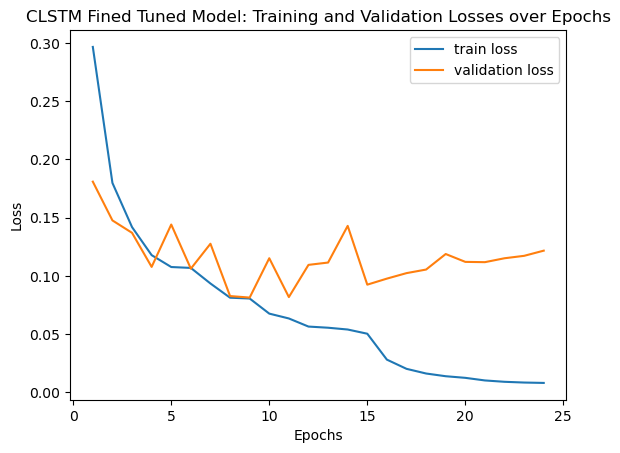

Best model's validation loss (0.08138599825158797) achieved at epoch 9
Best model's training loss (0.08058485605164717)
Total epochs (24)


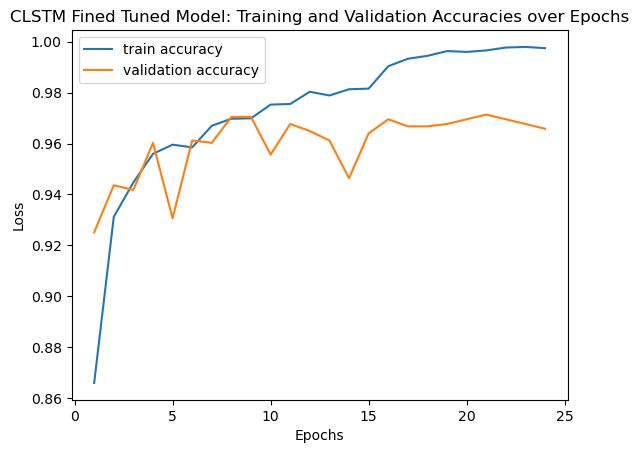

Best epoch's validation accuracy: 97.042514%
Best epoch's training accuracy: 96.987952%


In [45]:
plotting.plot_orchestrator_training_summary(best_param_orchestrator, "CLSTM Fined Tuned Model")

In [40]:
best_param_results = best_param_orchestrator.test(test_loader, best_param_orchestrator.th.best_model_weights)


Test Loss: 0.0487 | Test Acc: 98.6137%


              precision    recall  f1-score   support

     Snoring       0.98      0.99      0.99       539
   InfantCry       0.99      0.98      0.99       543

    accuracy                           0.99      1082
   macro avg       0.99      0.99      0.99      1082
weighted avg       0.99      0.99      0.99      1082



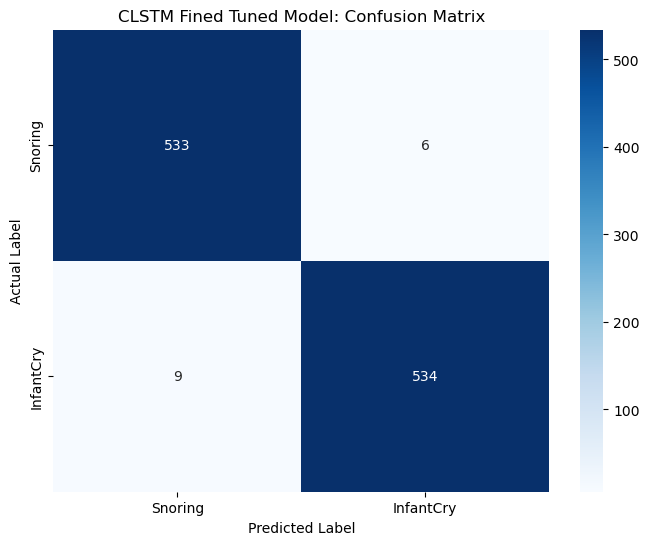

Test Loss: 0.0487 | Test Acc: 98.6137%


In [42]:
plotting.plot_test_results(best_param_results, "CLSTM Fined Tuned Model")